In [1]:
import os

datadir = os.path.join(os.getcwd(), "../datasets")
importdir = os.path.join(os.getcwd(), "../pdetransformer")

# Add `importdir` to sys.path to enable imports from pdetransformer
import sys
if importdir not in sys.path:
    sys.path.append(importdir)
    
import h5py

In [2]:
import torch

def generateSineDatasets(N: int, T: int, D: int, P: int):
    positions = torch.randn(N, 1, D, P).repeat(1, T, 1, 1)         # positions of points
    timestep_influence = torch.arange(0, 1.0, 1.0/T).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).repeat(N, 1, D, P)
    print(timestep_influence.shape)
    targets = torch.sin(positions+3*timestep_influence)              # sine of the positions as targets
    features = torch.zeros(N, T, 0, P)          # no additional features
    return (positions, targets, features, 1.0/T)

x, y, fx, dt = generateSineDatasets(100, 10, 2, 1000)
print(x.shape, y.shape, fx.shape, dt)

with h5py.File(os.path.join(datadir, "test.hdf5"), "w") as new_dset:
    sims = new_dset.create_group("sims")
    sims.attrs.update({
        "PDE": "2D-Sine",
        "Input Fields": [],
        "Input Fields Scheme": "",
        "Output Fields": ["sine_x", "sine_y"],
        "Output Fields Scheme": "xy",
        "Constants": ["Random1", "Random2"],
        "Dt": dt
    })
    for n in range(x.shape[0]):
        sim_group = sims.create_group(f"sim{n}")
        sim_group.create_dataset("x", data=x[n].numpy())
        sim_group.create_dataset("y", data=y[n].numpy())
        sim_group.create_dataset("fx", data=fx[n].numpy())
        sim_group.attrs.update({
            "Random1": float(torch.randn(1)),
            "Random2": float(torch.randn(1))
        })

torch.Size([100, 10, 2, 1000])
torch.Size([100, 10, 2, 1000]) torch.Size([100, 10, 2, 1000]) torch.Size([100, 10, 0, 1000]) 0.1


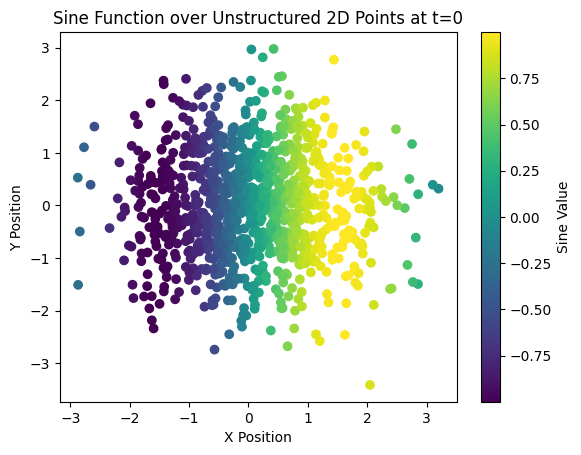

In [3]:
import matplotlib.pyplot as plt

# Visualize one sample
sample_idx = 0
time_idx = 0
plt.scatter(x[sample_idx, time_idx, 0].numpy(), x[sample_idx, time_idx, 1].numpy(), c=y[sample_idx, time_idx, 0].numpy())
plt.colorbar(label='Sine Value')
plt.title('Sine Function over Unstructured 2D Points at t=0')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

In [4]:
%load_ext autoreload
%autoreload 1

%aimport pdetransformer.data.pbdlu_dataloader.dataset
%aimport pdetransformer.data.pbdlu_dataloader.normalization

import pdetransformer.data.pbdlu_dataloader.dataset as dataset
import pdetransformer.data.pbdlu_dataloader.normalization as norm

/home/tobias/pde-transformer-idp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tobias/pde-transformer-idp/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/tobias/pde-transformer-idp/pdetransformer/data/pbdl_dataloader/dataset.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Success: Loaded /home/tobias/pde-transformer-idp/datasets/test with 100 simulations and 1 samples each.
Positions shape: (10, 2, 1000)
Targets shape: (10, 2, 1000)
Features shape: (10, 0, 1000)
Constants: [0.39666831 0.49227331]


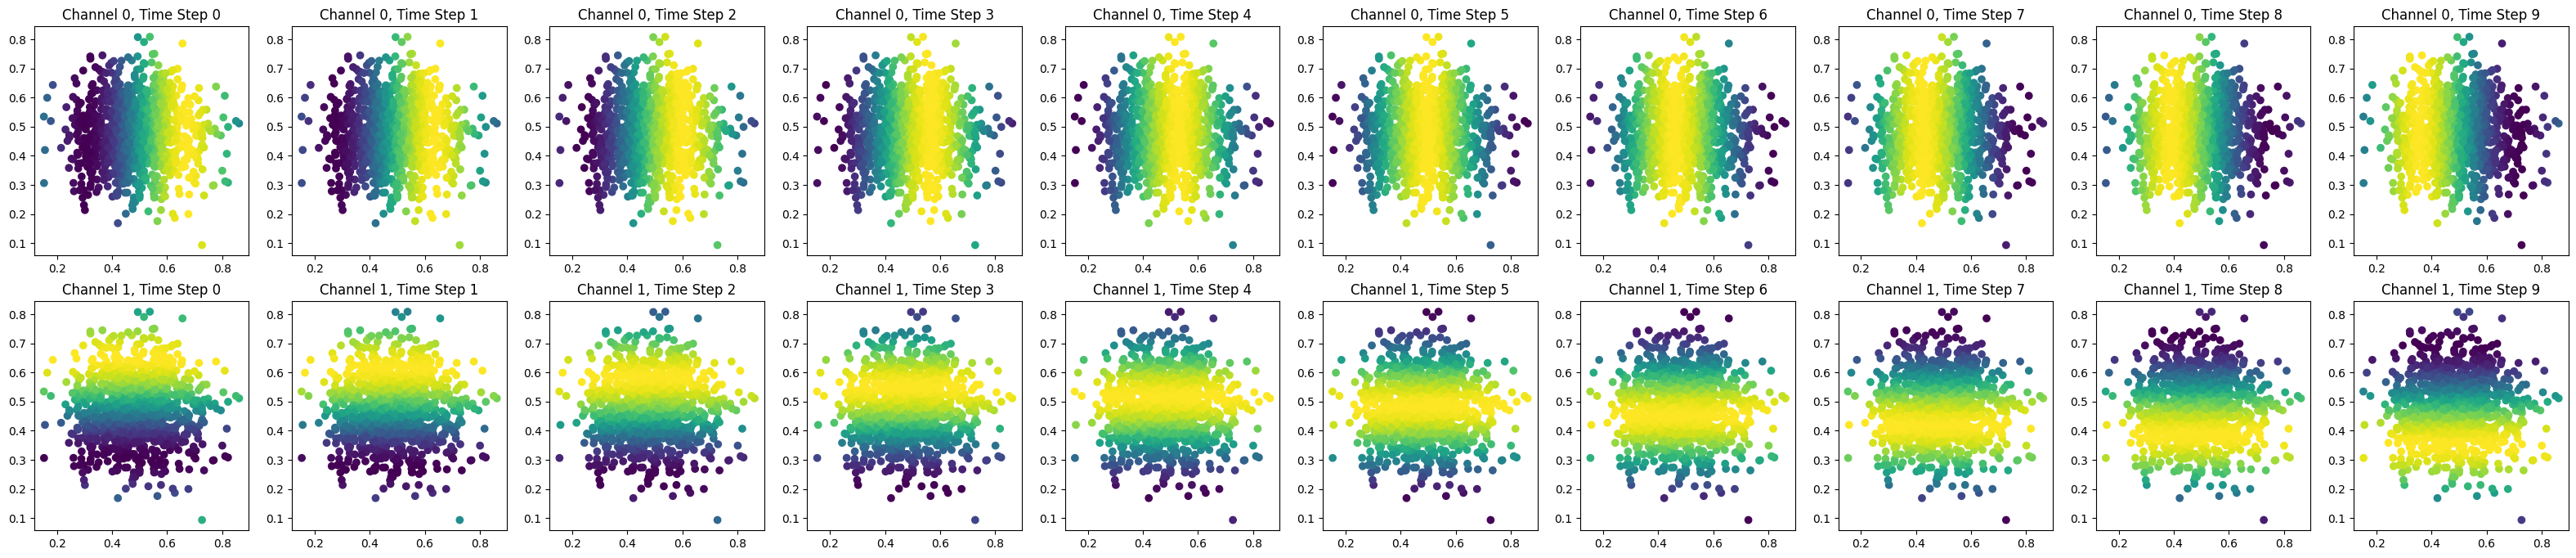

In [8]:
try:
    T = 10
    d = dataset.Dataset(
        dset_name="/home/tobias/pde-transformer-idp/datasets/test",
        time_steps=T,
        intermediate_time_steps=True,
        step_size=1,
        normalize_pos=norm.MinMaxNorm,
        normalize_in=norm.StdNorm,
        normalize_out=norm.StdNorm,
        normalize_const=norm.MinMaxNorm,
    )

    for sample_idx, sample in enumerate(d):
        sample_pos, sample_target, sample_feat, const = sample
        print("Positions shape:", sample_pos.shape)
        print("Targets shape:", sample_target.shape)
        print("Features shape:", sample_feat.shape)
        print("Constants:", const)
        break
    
    # Plot batch

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(2, T, figsize=(4*T, 8))
    for c in range(2):
        for t in range(T):
            sc = ax[c, t].scatter(
                sample_pos[t, 0, :],
                sample_pos[t, 1, :],
                c=sample_target[t, c, :],
                cmap='viridis'
            );
            ax[c, t].set_title(f'Channel {c}, Time Step {t}');
    plt.show()
except Exception as e:
    print("An error occurred:", e)
finally:
    d.dset.close()